# 👥 Dataset 4: Adult Census Income Prediction
## Kỹ thuật: Target Encoding + High Cardinality Categorical

**Pipeline:** EDA → Phân tích biến Categorical → Target Encoding → Training → Evaluation

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix
import category_encoders as ce
import warnings, os

import random

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})
sns.set_theme(style='whitegrid', palette='husl')

SAVE_DIR = '../results/adult_census'
os.makedirs(SAVE_DIR, exist_ok=True)
DATA_PATH = '../data/adult_census/adult.csv'
print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
df = pd.read_csv(DATA_PATH)
df = df.replace('?', np.nan).dropna()
for col in df.select_dtypes('object').columns:
    df[col] = df[col].str.strip()

df['income'] = (df['income'].str.strip() == '>50K').astype(int)
print(f'Shape: {df.shape}')
print(f'Income >50K rate: {df["income"].mean()*100:.2f}%')
df.head()

Shape: (30162, 15)
Income >50K rate: 24.89%


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,0
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,0
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,0
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,0
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,0


## 📊 2. EDA — Phân tích biến Categorical

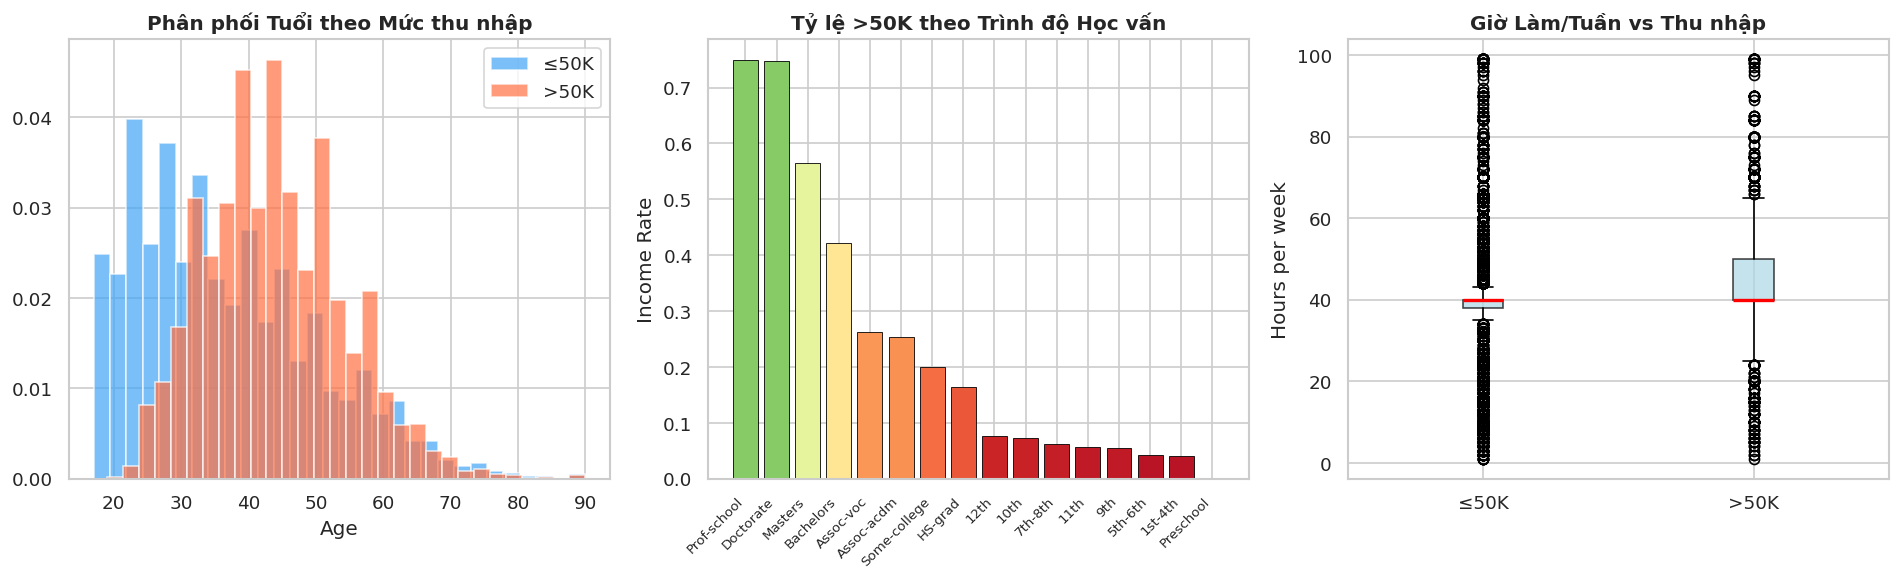

In [3]:
# Age distribution by income
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for cls, label, color in [(0, '≤50K', '#42A5F5'), (1, '>50K', '#FF7043')]:
    axes[0].hist(df[df['income']==cls]['age'], bins=30,
                 alpha=0.7, color=color, label=label, density=True)
axes[0].set_title('Phân phối Tuổi theo Mức thu nhập')
axes[0].set_xlabel('Age')
axes[0].legend()

# Education
edu_income = df.groupby('education')['income'].mean().sort_values(ascending=False)
bars = axes[1].bar(range(len(edu_income)), edu_income.values,
                   color=plt.cm.RdYlGn(edu_income.values), edgecolor='black', linewidth=0.5)
axes[1].set_xticks(range(len(edu_income)))
axes[1].set_xticklabels(edu_income.index, rotation=45, ha='right', fontsize=8)
axes[1].set_title('Tỷ lệ >50K theo Trình độ Học vấn')
axes[1].set_ylabel('Income Rate')

# Hours per week
axes[2].boxplot([df[df['income']==0]['hours.per.week'],
                 df[df['income']==1]['hours.per.week']],
                labels=['≤50K', '>50K'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Giờ Làm/Tuần vs Thu nhập')
axes[2].set_ylabel('Hours per week')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_eda_overview.png', bbox_inches='tight')
plt.show()

=== HIGH CARDINALITY COLUMNS ===
  workclass: 7 unique values
  occupation: 14 unique values
  native.country: 41 unique values


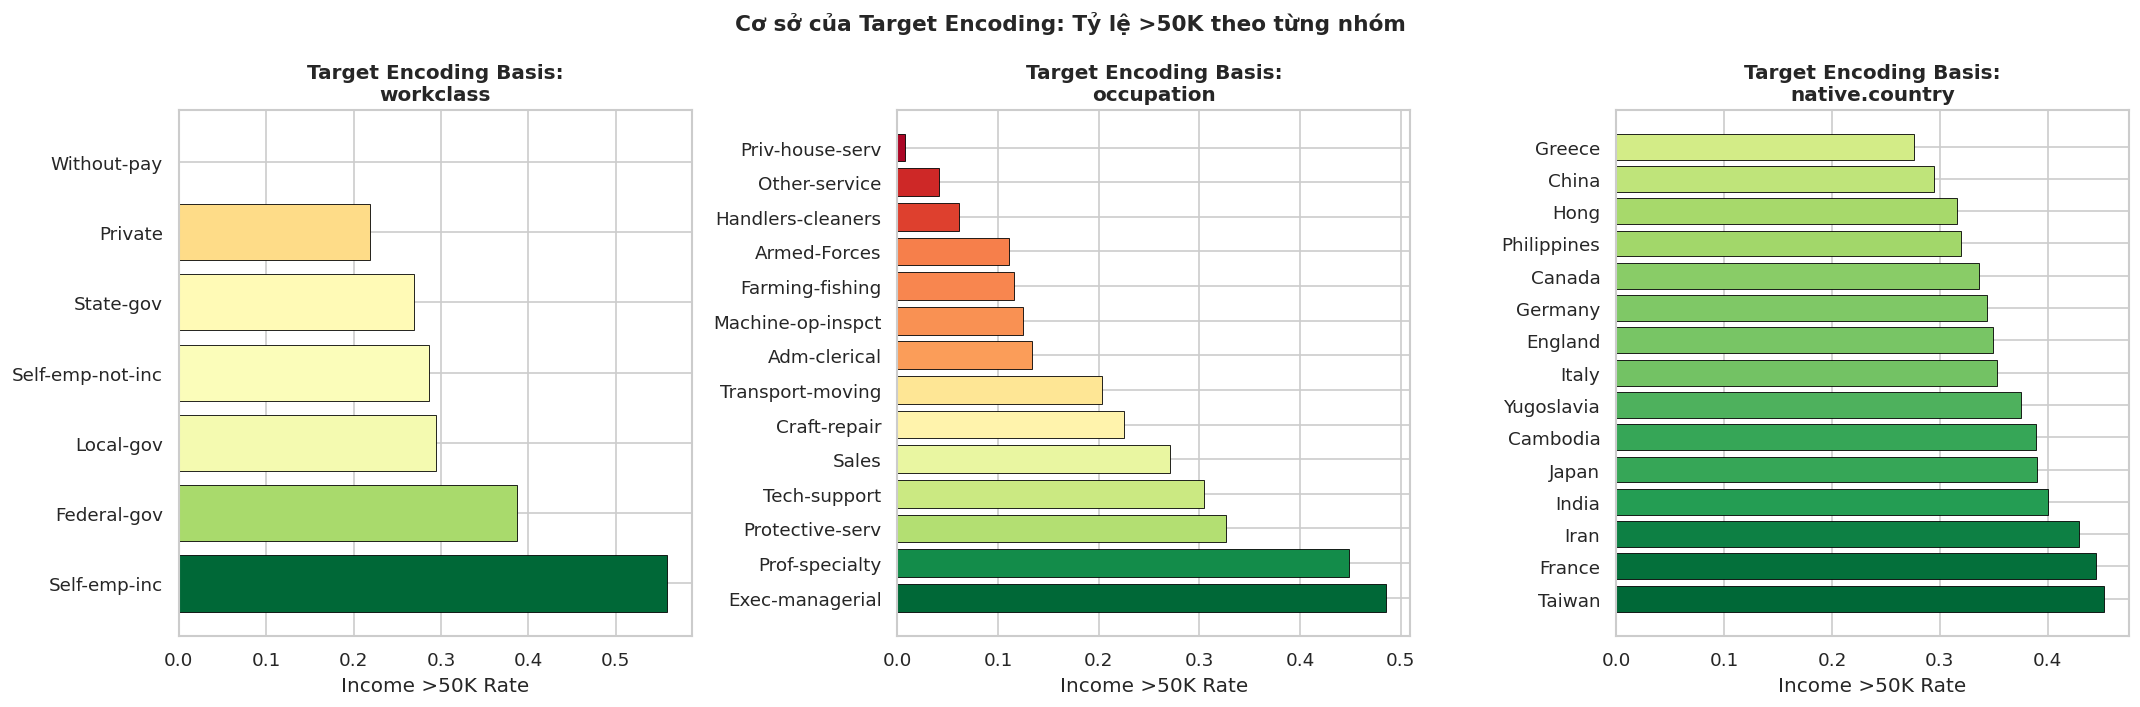

In [4]:
# High cardinality analysis
high_card_cols = ['workclass', 'occupation', 'native.country']
print('=== HIGH CARDINALITY COLUMNS ===')
for col in high_card_cols:
    print(f'  {col}: {df[col].nunique()} unique values')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col in zip(axes, high_card_cols):
    income_rate = df.groupby(col)['income'].mean().sort_values(ascending=False)
    # Limit to top 15
    income_rate = income_rate.head(15)
    bars = ax.barh(income_rate.index, income_rate.values,
                   color=plt.cm.RdYlGn(income_rate.values / income_rate.max()),
                   edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Income >50K Rate')
    ax.set_title(f'Target Encoding Basis:\n{col}')

plt.suptitle('Cơ sở của Target Encoding: Tỷ lệ >50K theo từng nhóm', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_target_encoding_basis.png', bbox_inches='tight')
plt.show()

## ⚙️ 3. Target Encoding

In [5]:
all_cat_cols = ['workclass', 'education', 'marital.status', 'occupation',
                'relationship', 'race', 'sex', 'native.country']
# Keep only cols that exist
all_cat_cols = [c for c in all_cat_cols if c in df.columns]

X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

encoder = ce.TargetEncoder(cols=all_cat_cols)
X_train_enc = encoder.fit_transform(X_train, y_train)
X_test_enc  = encoder.transform(X_test)

print('Before encoding (occupation sample):'); print(X_train['occupation'].value_counts().head(5))
print('\nAfter encoding (occupation sample):'); print(X_train_enc['occupation'].describe())

Before encoding (occupation sample):
occupation
Exec-managerial    3220
Prof-specialty     3215
Craft-repair       3209
Adm-clerical       2985
Sales              2915
Name: count, dtype: int64

After encoding (occupation sample):
count    24129.000000
mean         0.249052
std          0.150735
min          0.008562
25%          0.124514
50%          0.227485
75%          0.446034
max          0.483540
Name: occupation, dtype: float64


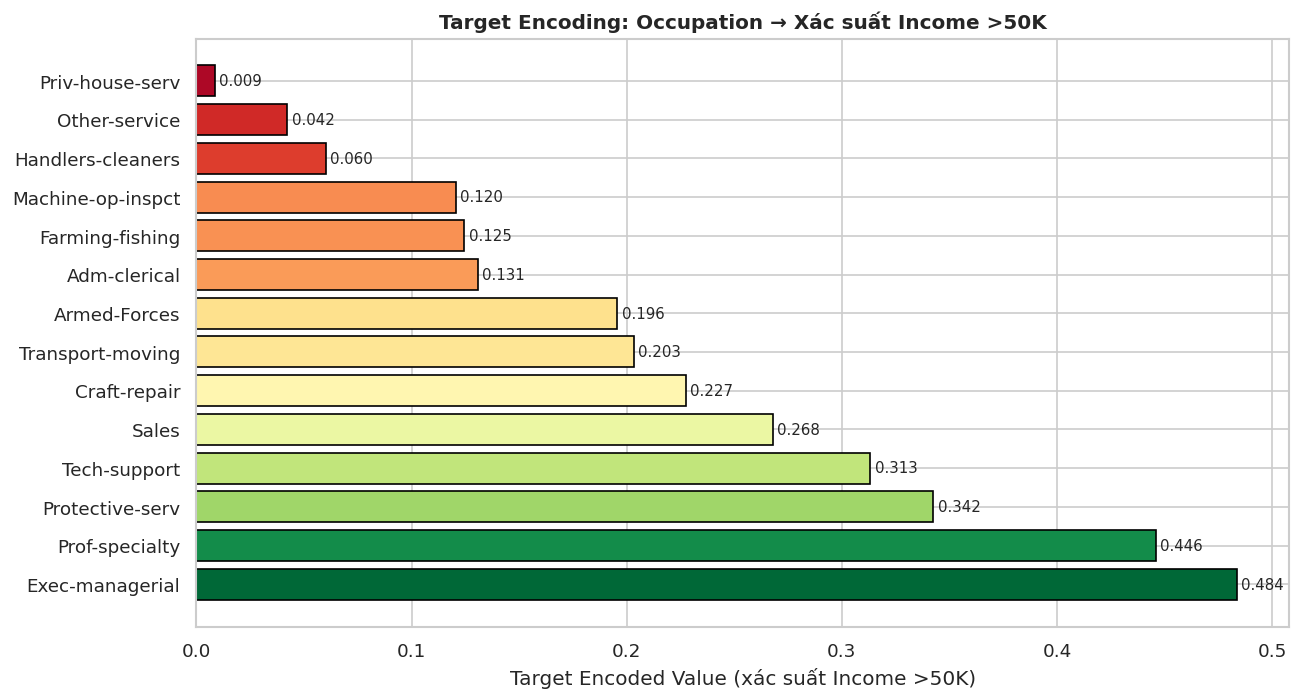

In [6]:
# Visualize encoding transformation
occ_enc = pd.DataFrame({
    'Original': X_train['occupation'],
    'Encoded':  X_train_enc['occupation']
}).drop_duplicates().sort_values('Encoded', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 6))
colors_occ = plt.cm.RdYlGn(occ_enc['Encoded'].values / occ_enc['Encoded'].max())
bars = ax.barh(occ_enc['Original'], occ_enc['Encoded'], color=colors_occ, edgecolor='black')
ax.set_xlabel('Target Encoded Value (xác suất Income >50K)')
ax.set_title('Target Encoding: Occupation → Xác suất Income >50K', fontweight='bold')
for bar, val in zip(bars, occ_enc['Encoded'].values):
    ax.text(val+0.002, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_occupation_target_encoding.png', bbox_inches='tight')
plt.show()

## 🤖 4. Training & Evaluation

In [7]:
models = {
    'Logistic Regression':   LogisticRegression(max_iter=1000),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=100, random_state=SEED)
}

results = {}
for name, mdl in models.items():
    mdl.fit(X_train_enc, y_train)
    preds = mdl.predict(X_test_enc)
    proba = mdl.predict_proba(X_test_enc)[:,1]
    acc  = accuracy_score(y_test, preds)
    rauc = roc_auc_score(y_test, proba)
    results[name] = {'preds': preds, 'Accuracy': acc, 'ROC-AUC': rauc}
    print(f'{name:25s} | Accuracy={acc:.4f} | ROC-AUC={rauc:.4f}')

Logistic Regression       | Accuracy=0.8377 | ROC-AUC=0.8911
Gradient Boosting         | Accuracy=0.8616 | ROC-AUC=0.9161


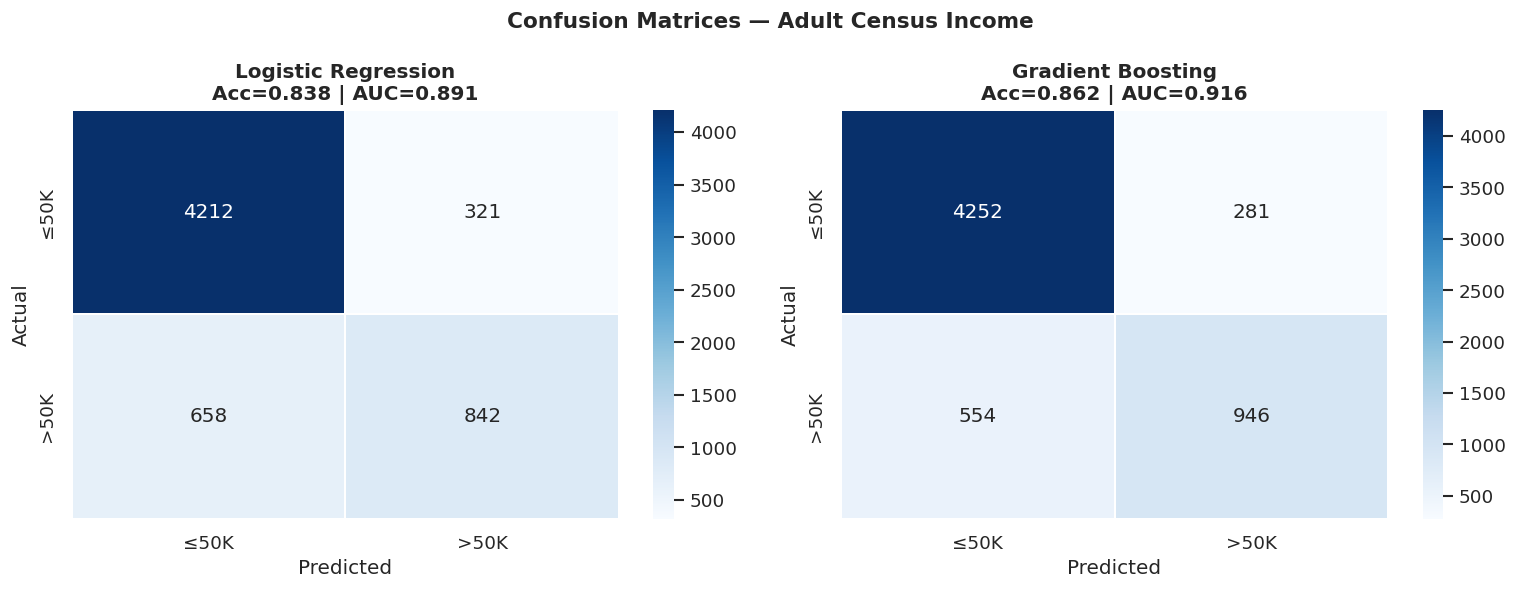

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['≤50K', '>50K'], yticklabels=['≤50K', '>50K'],
                linewidths=1)
    axes[i].set_title(f'{name}\nAcc={res["Accuracy"]:.3f} | AUC={res["ROC-AUC"]:.3f}')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Adult Census Income', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_confusion_matrices.png', bbox_inches='tight')
plt.show()

In [9]:
best_name = max(results, key=lambda m: results[m]['Accuracy'])
print(f'Best model: {best_name}')
print(classification_report(y_test, results[best_name]['preds'], target_names=['≤50K','>50K']))

with open(f'{SAVE_DIR}/report.txt', 'w') as f:
    f.write('Adult Census Income Classification Report\n' + '='*50 + '\n')
    for name, res in results.items():
        f.write(f'\n[{name}]\n')
        f.write(f'  Accuracy : {res["Accuracy"]:.4f}\n')
        f.write(f'  ROC-AUC  : {res["ROC-AUC"]:.4f}\n')
        f.write(classification_report(y_test, res['preds'], target_names=['<=50K','>50K']))

print('✅ Adult Census Experiment Completed! Results saved to', SAVE_DIR)

Best model: Gradient Boosting
              precision    recall  f1-score   support

        ≤50K       0.88      0.94      0.91      4533
        >50K       0.77      0.63      0.69      1500

    accuracy                           0.86      6033
   macro avg       0.83      0.78      0.80      6033
weighted avg       0.86      0.86      0.86      6033

✅ Adult Census Experiment Completed! Results saved to ../results/adult_census
